Fitting EGARCH(1,1,1) rolling model — this may take a moment...

── EGARCH(1,1,1) VOLATILITY FORECAST (Rolling 1-Step-Ahead) ──

[ Transition Period — June 2025 ]
      Date   close  forecast_vol
2025-06-24 6092.18      0.124874
2025-06-25 6092.16      0.112519
2025-06-26 6141.02      0.111669
2025-06-27 6173.07      0.102920
2025-06-30 6204.95      0.097232

[ Final Period — December 2025 ]
      Date   close  forecast_vol
2025-12-17 6721.43      0.141960
2025-12-18 6774.76      0.163399
2025-12-19 6834.50      0.150791
2025-12-22 6878.49      0.138261
2025-12-23 6909.79      0.129046
2025-12-24 6932.05      0.122391
2025-12-26 6929.94      0.117524
2025-12-29 6905.74      0.117355
2025-12-30 6896.24      0.123429
2025-12-31 6845.50      0.124850
IV columns: ['Date', 'IV_30D_Call(%)', 'IV_30D_Put(%)', 'IV_30D=(B2+C2)/2', 'Proxy=C2-B2(%)']
IV shape: (250, 5)
        Date  IV_30D_Call(%)  IV_30D_Put(%)  IV_30D=(B2+C2)/2  Proxy=C2-B2(%)
0 2025-01-02       14.337000      14.475429        

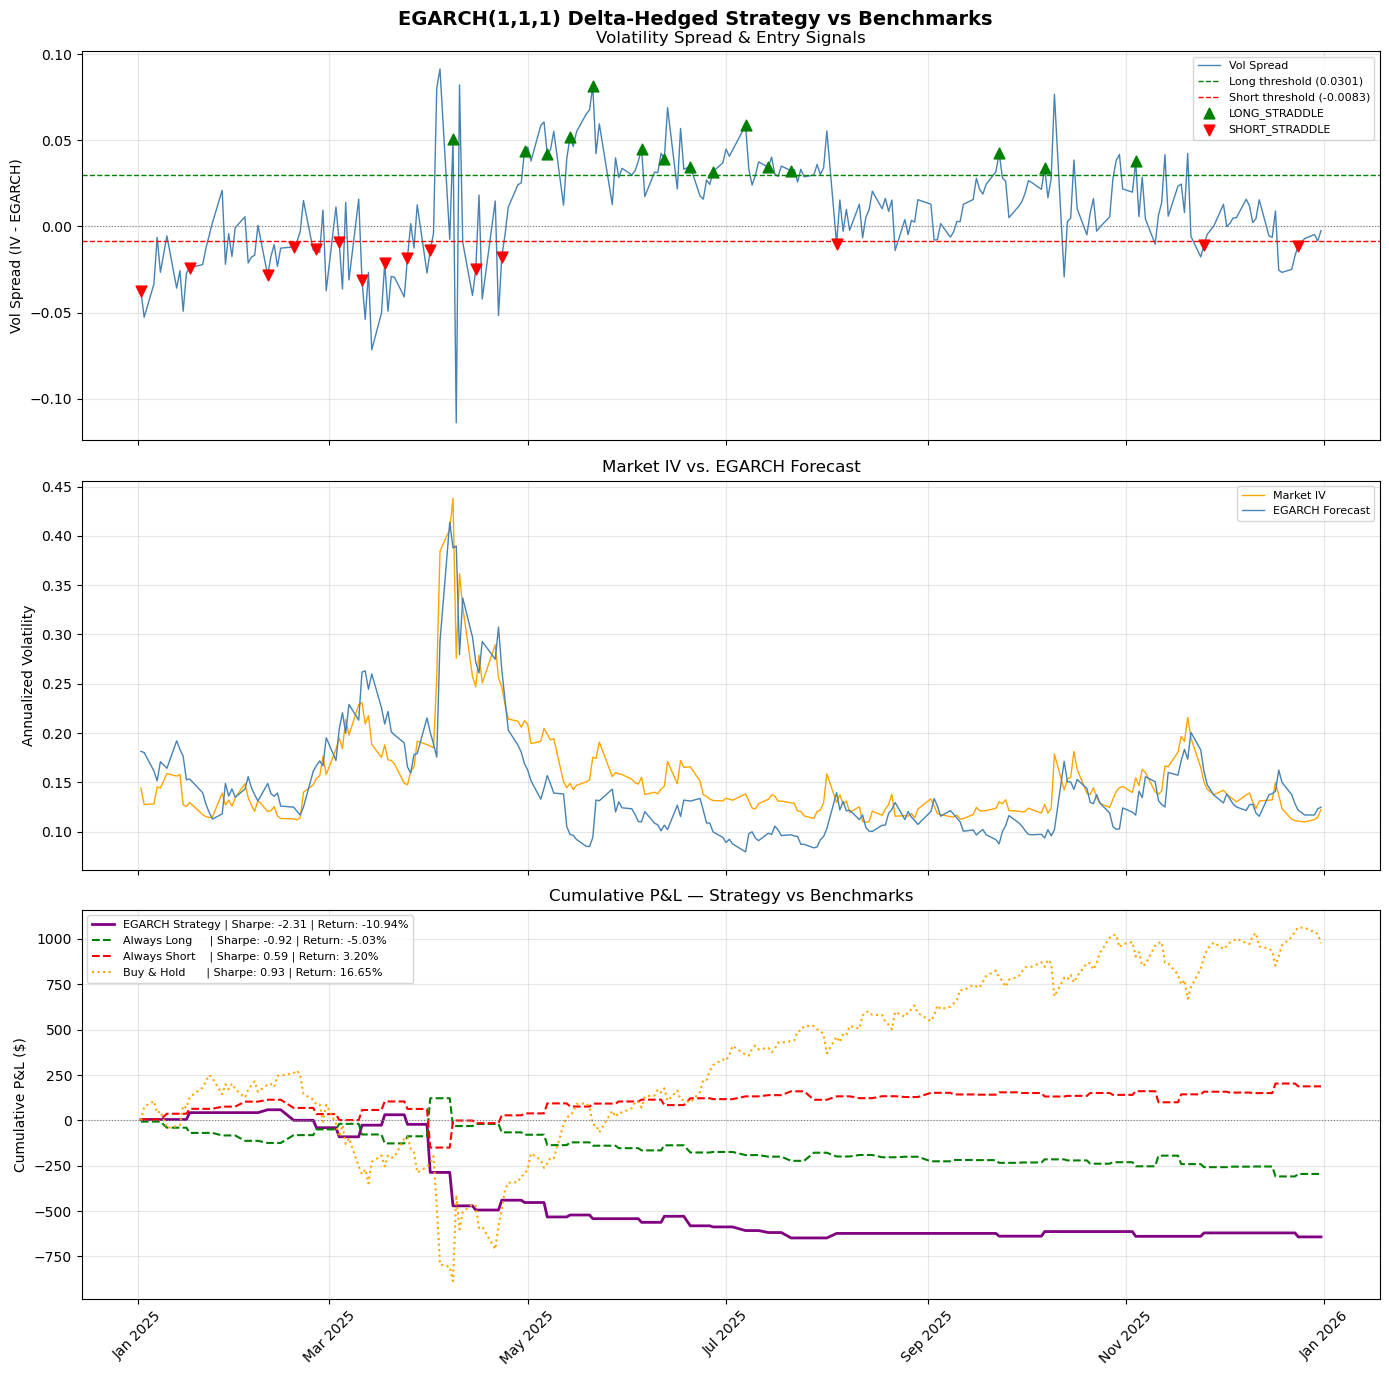


✓ Plot saved as egarch_benchmarks.png


In [1]:
import pandas as pd
pd.read_csv('SPY_Close_modeling_2.5y.csv')
pd.read_csv('SPY_Close_forecast_0.5y.csv')
!pip install arch


import numpy as np
import pandas as pd
from arch import arch_model

# ── 1. LOAD & COMBINE ──────────────────────────────────────────────────────────
df_25 = pd.read_csv('SPY_Close_modeling_2.5y.csv')
df_05 = pd.read_csv('SPY_Close_forecast_0.5y.csv')
df = pd.concat([df_25, df_05], axis=0).reset_index(drop=True)

# ── 2. CLEAN & SORT ────────────────────────────────────────────────────────────
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# ── 3. EGARCH VOLATILITY FUNCTION ─────────────────────────────────────────────
def get_egarch_forecast(df: pd.DataFrame, col_name: str,
                        p: int = 1, q: int = 1, o: int = 1,
                        rolling_window: int = 30) -> pd.Series:
    """
    Calculates annualized EGARCH volatility forecast using a rolling window.

    Parameters:
        df             : DataFrame containing the return column
        col_name       : Column name of log returns (as decimals, e.g. 0.01)
        p              : ARCH order (lagged squared residuals). Default = 1
        q              : GARCH order (lagged variance). Default = 1
        o              : Asymmetry/leverage order (GJR/EGARCH term). Default = 1
        rolling_window : Number of days for the initial training window.
                         Model is re-fitted at each step beyond this. Default = 30

    Returns:
        pd.Series of 1-step-ahead annualized EGARCH volatility forecasts,
        aligned to df's index. Values before `rolling_window` are NaN.

    Notes:
        - Uses log returns scaled to percentage points internally (x100)
          because ARCH/EGARCH optimizers work best at that scale.
        - EGARCH models log(σ²), so variance is always positive — no
          constraints needed unlike standard GARCH.
        - Leverage effect: negative shocks (o term) increase volatility
          more than positive shocks of the same magnitude.
        - One-step-ahead forecast is annualized: σ_daily * sqrt(252).
    """
    TRADING_DAYS = 252
    returns = df[col_name].values * 100  # scale to % for numerical stability
    n = len(returns)
    forecasts = np.full(n, np.nan)

    for t in range(rolling_window, n):
        train = returns[:t]
        try:
            model = arch_model(
                train,
                vol='EGARCH',
                p=p,       # ARCH term: sensitivity to past shocks
                o=o,       # Leverage term: asymmetry (negative shock effect)
                q=q,       # GARCH term: persistence of past variance
                dist='normal'
            )
            res = model.fit(disp='off', show_warning=False)

            # 1-step-ahead forecast
            fc = res.forecast(horizon=1, reindex=False)
            daily_var_pct = fc.variance.values[-1, 0]  # in % units squared

            # Convert: (σ% / 100)² * 252 → annualized variance in decimal
            annual_vol = np.sqrt(daily_var_pct / 100**2 * TRADING_DAYS)
            forecasts[t] = annual_vol

        except Exception:
            forecasts[t] = np.nan

    return pd.Series(forecasts, index=df.index)

# ── 4. RUN MODEL ───────────────────────────────────────────────────────────────
print("Fitting EGARCH(1,1,1) rolling model — this may take a moment...")
df['forecast_vol'] = get_egarch_forecast(
    df,
    col_name='log_return',
    p=1, q=1, o=1,
    rolling_window=30
)

# ── 5. PRINT RESULTS ───────────────────────────────────────────────────────────
print("\n── EGARCH(1,1,1) VOLATILITY FORECAST (Rolling 1-Step-Ahead) ──")

print("\n[ Transition Period — June 2025 ]")
june_mask = df['Date'].dt.month == 6
print(df[june_mask].tail(5)[['Date', 'close', 'forecast_vol']].to_string(index=False))

print("\n[ Final Period — December 2025 ]")
print(df.tail(10)[['Date', 'close', 'forecast_vol']].to_string(index=False))


import pandas as pd
import numpy as np
from arch import arch_model

# ── 1. LOAD DATA ───────────────────────────────────────────────────────────────
df_25 = pd.read_csv('SPY_Close_modeling_2.5y.csv')
df_05 = pd.read_csv('SPY_Close_forecast_0.5y.csv')
iv_df = pd.read_excel('options_data_2025.xlsx', sheet_name='IV')

# ── 2. CHECK IV SHEET ──────────────────────────────────────────────────────────
print("IV columns:", iv_df.columns.tolist())
print("IV shape:", iv_df.shape)
print(iv_df.head(3))

# ── 3. COMBINE & SORT PRICE DATA ───────────────────────────────────────────────
df = pd.concat([df_25, df_05], axis=0).reset_index(drop=True)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# ── 4. FORMAT IV DATE ──────────────────────────────────────────────────────────
iv_df['Date'] = pd.to_datetime(iv_df['Date'])

# ── 5. EGARCH FUNCTION ─────────────────────────────────────────────────────────
def get_egarch_forecast(df: pd.DataFrame, col_name: str,
                        p: int = 1, q: int = 1, o: int = 1) -> pd.Series:
    """
    Fits a single EGARCH(1,1,1) model and returns in-sample
    annualized conditional volatility.

    Parameters:
        df       : DataFrame containing the return column
        col_name : Column name of log returns
        p        : ARCH order. Default = 1
        q        : GARCH order. Default = 1
        o        : Leverage/asymmetry order. Default = 1

    Returns:
        pd.Series of annualized EGARCH conditional volatility
    """
    TRADING_DAYS = 252
    returns = df[col_name] * 100  # scale to % for numerical stability

    model = arch_model(returns, vol='EGARCH', p=p, o=o, q=q, dist='normal')
    res = model.fit(disp='off', show_warning=False)

    daily_vol = res.conditional_volatility / 100
    annual_vol = daily_vol * np.sqrt(TRADING_DAYS)

    return pd.Series(annual_vol.values, index=df.index)

# ── 6. RUN EGARCH ──────────────────────────────────────────────────────────────
print("Fitting EGARCH(1,1,1)...")
df['forecast_vol'] = get_egarch_forecast(df, col_name='log_return', p=1, q=1, o=1)

print("\n✓ df columns:", df.columns.tolist())
print("✓ forecast_vol sample:\n", df['forecast_vol'].tail(3))

# ── 7. MERGE EGARCH WITH IV DATA ───────────────────────────────────────────────
merged_df = pd.merge(
    iv_df,
    df[['Date', 'forecast_vol']],
    on='Date',
    how='inner'
)

print(f"\n✓ Merged rows: {len(merged_df)}")
print("✓ Merged columns:", merged_df.columns.tolist())

# ── 8. DEFINE IV COLUMN ────────────────────────────────────────────────────────
IV_COL = 'IV_30D=(B2+C2)/2'

# ── 9. CALCULATE VOLATILITY SPREAD ────────────────────────────────────────────
merged_df['vol_spread'] = merged_df[IV_COL] - merged_df['forecast_vol']

print("\n── SPREAD DISTRIBUTION ──")
print(merged_df['vol_spread'].describe())

# ── 10. DYNAMIC QUARTILE THRESHOLDS ───────────────────────────────────────────
lower = merged_df['vol_spread'].quantile(0.25)
upper = merged_df['vol_spread'].quantile(0.75)

print(f"\nSuggested lower threshold : {lower:.4f}")
print(f"Suggested upper threshold : {upper:.4f}")

# ── 11. GENERATE TRADE SIGNALS ─────────────────────────────────────────────────
merged_df['signal'] = 'Neutral'
merged_df.loc[merged_df['vol_spread'] > upper, 'signal'] = 'Sell Straddle'
merged_df.loc[merged_df['vol_spread'] < lower, 'signal'] = 'Buy Straddle'

# ── 12. PRINT RESULTS ─────────────────────────────────────────────────────────
print("\n── VOLATILITY SPREAD (Market IV vs. EGARCH Forecast) ──")
cols_to_show = ['Date', IV_COL, 'forecast_vol', 'vol_spread', 'signal']
print(merged_df[cols_to_show].tail(10).to_string(index=False))

print("\n── SUMMARY STATS ──")
print(f"  Mean Spread : {merged_df['vol_spread'].mean():.4f}")
print(f"  Max Spread  : {merged_df['vol_spread'].max():.4f}")
print(f"  Min Spread  : {merged_df['vol_spread'].min():.4f}")
print(f"  Std Dev     : {merged_df['vol_spread'].std():.4f}")

print("\n── SIGNAL COUNTS ──")
print(merged_df['signal'].value_counts().to_string())


import pandas as pd
import numpy as np
from scipy.stats import norm
from arch import arch_model
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ══════════════════════════════════════════════════════════════════════════════
# SETTINGS
# ══════════════════════════════════════════════════════════════════════════════
CYCLE_LENGTH        = 5
IV_COL              = 'IV_30D=(B2+C2)/2'
STRADDLE_COL        = '30D Constant-Maturity Straddle'
TRANS_COST          = 0.001
BID_ASK_SPREAD      = 0.002
BID_ASK_TEST_VALUES = [0.001, 0.002, 0.003, 0.005, 0.010]

# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — LOAD DATA
# ══════════════════════════════════════════════════════════════════════════════
print("── LOADING DATA ──")
df_25       = pd.read_csv('SPY_Close_modeling_2.5y.csv')
df_05       = pd.read_csv('SPY_Close_forecast_0.5y.csv')
iv_df       = pd.read_excel('options_data_2025.xlsx', sheet_name='IV')
delta_df    = pd.read_excel('options_data_2025.xlsx', sheet_name='Delta_Trading')  # ← changed
straddle_df = pd.read_excel('options_data_2025.xlsx', sheet_name='Straddle')

# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — COMBINE & SORT PRICE DATA
# ══════════════════════════════════════════════════════════════════════════════
df = pd.concat([df_25, df_05], axis=0).reset_index(drop=True)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

iv_df['Date']       = pd.to_datetime(iv_df['Date'])
delta_df['Date']    = pd.to_datetime(delta_df['Date'])
straddle_df['Date'] = pd.to_datetime(straddle_df['Date'])
print("✓ Data loaded")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — EGARCH VOLATILITY
# ══════════════════════════════════════════════════════════════════════════════
def get_egarch_forecast(df: pd.DataFrame, col_name: str,
                        p: int = 1, q: int = 1, o: int = 1) -> pd.Series:
    TRADING_DAYS = 252
    returns      = df[col_name] * 100
    model        = arch_model(returns, vol='EGARCH', p=p, o=o, q=q, dist='normal')
    res          = model.fit(disp='off', show_warning=False)
    daily_vol    = res.conditional_volatility / 100
    annual_vol   = daily_vol * np.sqrt(TRADING_DAYS)
    return pd.Series(annual_vol.values, index=df.index)

print("Fitting EGARCH(1,1,1)...")
df['forecast_vol'] = get_egarch_forecast(df, col_name='log_return', p=1, q=1, o=1)
print("✓ EGARCH calculated")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — MERGE ALL DATA
# ══════════════════════════════════════════════════════════════════════════════
merged_df = pd.merge(iv_df, df[['Date', 'close', 'forecast_vol']], on='Date', how='inner')

merged_df = pd.merge(
    merged_df,
    delta_df[['Date', 'Underlying (SPX Spot)', 'ATM Strike',
              'RF_1M/100', 'DTE_F = FrontExp - Date',
              'Call Delta（Trading）', 'Put Delta (Trading)',
              'Straddle Delta']],
    on='Date', how='inner'
)

merged_df = pd.merge(
    merged_df,
    straddle_df[['Date', STRADDLE_COL, 'PnL', 'Return']],
    on='Date', how='inner'
)
print(f"✓ Merged rows    : {len(merged_df)}")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 5 — BLACK-SCHOLES DELTAS (VERIFICATION ONLY)
# ══════════════════════════════════════════════════════════════════════════════
def calculate_bs_deltas(row):
    S          = row['Underlying (SPX Spot)']
    K          = row['ATM Strike']
    r          = row['RF_1M/100']
    T          = row['DTE_F = FrontExp - Date'] / 365
    sigma_call = row['IV_30D_Call(%)'] / 100
    sigma_put  = row['IV_30D_Put(%)']  / 100

    d1_call    = (np.log(S / K) + (r + 0.5 * sigma_call ** 2) * T) / (sigma_call * np.sqrt(T))
    delta_call = norm.cdf(d1_call)

    d1_put     = (np.log(S / K) + (r + 0.5 * sigma_put  ** 2) * T) / (sigma_put  * np.sqrt(T))
    delta_put  = norm.cdf(d1_put) - 1

    straddle_delta = delta_call + delta_put
    return pd.Series([delta_call, delta_put, straddle_delta])

merged_df[['BS_Call_Delta', 'BS_Put_Delta', 'BS_Straddle_Delta']] = merged_df.apply(
    calculate_bs_deltas, axis=1
)
print("✓ Black-Scholes deltas calculated (verification)")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 6 — VOL SPREAD + DYNAMIC THRESHOLDS
# ══════════════════════════════════════════════════════════════════════════════
merged_df['vol_spread'] = merged_df[IV_COL] - merged_df['forecast_vol']

LOWER_THRESH = merged_df['vol_spread'].quantile(0.25)
UPPER_THRESH = merged_df['vol_spread'].quantile(0.75)
print(f"\n✓ Thresholds (EGARCH-based)")
print(f"  Lower (SHORT_STRADDLE) : {LOWER_THRESH:.4f}")
print(f"  Upper (LONG_STRADDLE)  : {UPPER_THRESH:.4f}")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 7 — 5-DAY CYCLE + SIGNALS
# ══════════════════════════════════════════════════════════════════════════════
merged_df['cycle_day']    = (np.arange(len(merged_df)) % CYCLE_LENGTH) + 1
merged_df['entry_signal'] = 'HOLD/NONE'

day_1_mask = (merged_df['cycle_day'] == 1)
merged_df.loc[day_1_mask & (merged_df['vol_spread'] >  UPPER_THRESH), 'entry_signal'] = 'LONG_STRADDLE'
merged_df.loc[day_1_mask & (merged_df['vol_spread'] <  LOWER_THRESH), 'entry_signal'] = 'SHORT_STRADDLE'

print(f"\n✓ Signals generated")
print(f"  {merged_df[day_1_mask]['entry_signal'].value_counts().to_dict()}")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 8 — DELTA HEDGING (USING TRADING DELTAS)
# ══════════════════════════════════════════════════════════════════════════════
merged_df['Straddle_Delta_Trading'] = (
    merged_df['Call Delta（Trading）'] + merged_df['Put Delta (Trading)']
)

merged_df['active_pos'] = merged_df['entry_signal'].replace('HOLD/NONE', np.nan).ffill()

def calculate_share_hedge(row):
    if row['cycle_day'] == 5:                 return 0
    if row['active_pos'] == 'LONG_STRADDLE':  return -row['Straddle_Delta_Trading']
    if row['active_pos'] == 'SHORT_STRADDLE': return  row['Straddle_Delta_Trading']
    return 0

merged_df['share_hedge_qty']   = merged_df.apply(calculate_share_hedge, axis=1)
merged_df['daily_hedge_trade'] = merged_df['share_hedge_qty'].diff().fillna(0)
merged_df.loc[merged_df['cycle_day'] == 1, 'daily_hedge_trade'] = merged_df['share_hedge_qty']
print("✓ Delta hedging calculated")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 9 — HELPER: RUN ONE BACKTEST
# ══════════════════════════════════════════════════════════════════════════════
def run_backtest(merged_df, signal_col, bid_ask, trans_cost,
                 straddle_col, always_signal=None):
    results = []

    for i in range(len(merged_df)):
        row = merged_df.iloc[i]

        if row['cycle_day'] != 1:
            continue

        signal = always_signal if always_signal else row[signal_col]

        if signal == 'HOLD/NONE':
            continue

        exit_idx = i + 4
        if exit_idx >= len(merged_df):
            continue

        exit_row  = merged_df.iloc[exit_idx]
        mid_entry = row[straddle_col]
        mid_exit  = exit_row[straddle_col]

        if signal == 'LONG_STRADDLE':
            entry_price  = mid_entry * (1 + bid_ask)
            exit_price   = mid_exit  * (1 - bid_ask)
            straddle_pnl = exit_price - entry_price
        else:
            entry_price  = mid_entry * (1 - bid_ask)
            exit_price   = mid_exit  * (1 + bid_ask)
            straddle_pnl = entry_price - exit_price

        hedge_pnl = 0
        if always_signal is None:
            for d in range(i, min(i + 5, len(merged_df) - 1)):
                hedge_row    = merged_df.iloc[d]
                next_row     = merged_df.iloc[d + 1]
                price_change = (next_row['Underlying (SPX Spot)']
                                - hedge_row['Underlying (SPX Spot)'])
                hedge_pnl   += hedge_row['share_hedge_qty'] * price_change

        transaction_cost = mid_entry * trans_cost
        total_pnl        = straddle_pnl + hedge_pnl - transaction_cost

        results.append({
            'Date'            : row['Date'],
            'signal'          : signal,
            'entry_price'     : entry_price,
            'exit_price'      : exit_price,
            'straddle_pnl'    : straddle_pnl,
            'hedge_pnl'       : hedge_pnl,
            'transaction_cost': transaction_cost,
            'Net PnL'         : total_pnl,
            'vol_spread'      : row['vol_spread'],
            'forecast_vol'    : row['forecast_vol'],
            IV_COL            : row[IV_COL],
        })

    results_df = pd.DataFrame(results)
    if not results_df.empty:
        results_df['Cumulative PnL'] = results_df['Net PnL'].cumsum()
    return results_df

# ══════════════════════════════════════════════════════════════════════════════
# STEP 10 — RUN STRATEGY + BENCHMARKS
# ══════════════════════════════════════════════════════════════════════════════
results_df      = run_backtest(merged_df, 'entry_signal', BID_ASK_SPREAD,
                               TRANS_COST, STRADDLE_COL)
always_long_df  = run_backtest(merged_df, 'entry_signal', BID_ASK_SPREAD,
                               TRANS_COST, STRADDLE_COL,
                               always_signal='LONG_STRADDLE')
always_short_df = run_backtest(merged_df, 'entry_signal', BID_ASK_SPREAD,
                               TRANS_COST, STRADDLE_COL,
                               always_signal='SHORT_STRADDLE')

merged_df['buy_hold_pnl'] = merged_df['Underlying (SPX Spot)'].diff().fillna(0)
merged_df['cum_buy_hold'] = merged_df['buy_hold_pnl'].cumsum()

merged_df = pd.merge(
    merged_df,
    results_df[['Date', 'Cumulative PnL']].rename(
        columns={'Cumulative PnL': 'cum_strategy_pnl'}),
    on='Date', how='left'
)
merged_df['cum_strategy_pnl'] = merged_df['cum_strategy_pnl'].ffill().fillna(0)

merged_df = pd.merge(
    merged_df,
    always_long_df[['Date', 'Cumulative PnL']].rename(
        columns={'Cumulative PnL': 'cum_always_long'}),
    on='Date', how='left'
)
merged_df['cum_always_long'] = merged_df['cum_always_long'].ffill().fillna(0)

merged_df = pd.merge(
    merged_df,
    always_short_df[['Date', 'Cumulative PnL']].rename(
        columns={'Cumulative PnL': 'cum_always_short'}),
    on='Date', how='left'
)
merged_df['cum_always_short'] = merged_df['cum_always_short'].ffill().fillna(0)

print("✓ Strategy and benchmarks calculated")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 11 — PERFORMANCE METRICS
# ══════════════════════════════════════════════════════════════════════════════
def calc_sharpe(pnl_series, periods=52):
    mean = pnl_series.mean()
    std  = pnl_series.std()
    return (mean / std) * np.sqrt(periods) if std != 0 else 0

def calc_max_drawdown(cum_series):
    return (cum_series - cum_series.cummax()).min()

def calc_win_rate(pnl_series):
    wins  = (pnl_series > 0).sum()
    total = (pnl_series != 0).sum()
    return wins / total if total != 0 else 0

def calc_return_pct(cum_pnl, start_price):
    return (cum_pnl / start_price) * 100

def interpret_sharpe(sharpe: float) -> str:
    if sharpe >= 2.0:   return "Strong (≥ 2.0)"
    elif sharpe >= 1.0: return "Solid (≥ 1.0)"
    elif sharpe >= 0.5: return "Moderate (0.5–1.0)"
    else:               return "Weak (< 0.5)"

start_price = merged_df['Underlying (SPX Spot)'].iloc[0]

metrics = {
    'EGARCH Strategy': {
        'Final PnL'   : results_df['Cumulative PnL'].iloc[-1],
        'Return %'    : calc_return_pct(results_df['Cumulative PnL'].iloc[-1], start_price),
        'Sharpe'      : calc_sharpe(results_df['Net PnL'], periods=52),
        'Max Drawdown': calc_max_drawdown(results_df['Cumulative PnL']),
        'DD %'        : calc_return_pct(calc_max_drawdown(results_df['Cumulative PnL']), start_price),
        'Win Rate'    : calc_win_rate(results_df['Net PnL'])
    },
    'Always Long': {
        'Final PnL'   : always_long_df['Cumulative PnL'].iloc[-1],
        'Return %'    : calc_return_pct(always_long_df['Cumulative PnL'].iloc[-1], start_price),
        'Sharpe'      : calc_sharpe(always_long_df['Net PnL'], periods=52),
        'Max Drawdown': calc_max_drawdown(always_long_df['Cumulative PnL']),
        'DD %'        : calc_return_pct(calc_max_drawdown(always_long_df['Cumulative PnL']), start_price),
        'Win Rate'    : calc_win_rate(always_long_df['Net PnL'])
    },
    'Always Short': {
        'Final PnL'   : always_short_df['Cumulative PnL'].iloc[-1],
        'Return %'    : calc_return_pct(always_short_df['Cumulative PnL'].iloc[-1], start_price),
        'Sharpe'      : calc_sharpe(always_short_df['Net PnL'], periods=52),
        'Max Drawdown': calc_max_drawdown(always_short_df['Cumulative PnL']),
        'DD %'        : calc_return_pct(calc_max_drawdown(always_short_df['Cumulative PnL']), start_price),
        'Win Rate'    : calc_win_rate(always_short_df['Net PnL'])
    },
    'Buy & Hold': {
        'Final PnL'   : merged_df['cum_buy_hold'].iloc[-1],
        'Return %'    : calc_return_pct(merged_df['cum_buy_hold'].iloc[-1], start_price),
        'Sharpe'      : calc_sharpe(merged_df['buy_hold_pnl'], periods=252),
        'Max Drawdown': calc_max_drawdown(merged_df['cum_buy_hold']),
        'DD %'        : calc_return_pct(calc_max_drawdown(merged_df['cum_buy_hold']), start_price),
        'Win Rate'    : calc_win_rate(merged_df['buy_hold_pnl'])
    }
}

# ══════════════════════════════════════════════════════════════════════════════
# STEP 12 — PRINT RESULTS
# ══════════════════════════════════════════════════════════════════════════════
print("\n── TRADE RESULTS (EGARCH Strategy) ──")
cols = ['Date', 'signal', 'entry_price', 'exit_price',
        'straddle_pnl', 'hedge_pnl', 'transaction_cost', 'Net PnL', 'Cumulative PnL']
print(results_df[cols].tail(10).to_string(index=False))

print("\n══ FULL BENCHMARK COMPARISON ══")
print(f"{'Strategy':<22} {'Final PnL':>10} {'Return%':>9} {'Sharpe':>8} {'Max DD':>10} {'DD%':>7} {'Win Rate':>10}")
print("─" * 82)
for name, m in metrics.items():
    print(
        f"{name:<22}"
        f" {'$'+str(round(m['Final PnL'],2)):>10}"
        f" {m['Return %']:>8.2f}%"
        f" {m['Sharpe']:>8.2f}  → {interpret_sharpe(m['Sharpe'])}"
        f" {'$'+str(round(m['Max Drawdown'],2)):>10}"
        f" {m['DD %']:>6.2f}%"
        f" {m['Win Rate']:>9.1%}"
    )

print("\n── SHARPE CONTEXT ──")
print("  ≥ 2.0  : Strong")
print("  ≥ 1.0  : Solid — common target for fund managers")
print("  0.5–1.0: Moderate")
print("  < 0.5  : Weak")
print("  Note   : Strategy Sharpe uses weekly (52) periods; Buy & Hold uses daily (252).")
print("  ⚠️  High Sharpe ≠ no risk — tail/liquidity/leverage risk may not be captured.")
print("  ⚠️  Not financial advice — consult a professional for investment decisions.")

print("\n── SIGNAL BREAKDOWN (EGARCH Strategy) ──")
signal_pnl = results_df.groupby('signal')['Net PnL'].agg(['sum', 'mean', 'count'])
signal_pnl.columns = ['Total PnL', 'Avg PnL', 'Count']
print(signal_pnl.to_string())

# ══════════════════════════════════════════════════════════════════════════════
# STEP 13 — BID/ASK SENSITIVITY TEST
# ══════════════════════════════════════════════════════════════════════════════
print("\n── BID/ASK SPREAD SENSITIVITY (EGARCH Strategy) ──")
print(f"{'Spread':>8} {'Final PnL':>12} {'Sharpe':>8} {'Win Rate':>10} {'Max DD':>12}")
print("─" * 56)

for spread in BID_ASK_TEST_VALUES:
    test_df  = run_backtest(merged_df, 'entry_signal', spread,
                            TRANS_COST, STRADDLE_COL)
    if test_df.empty:
        continue
    sharpe   = calc_sharpe(test_df['Net PnL'], periods=52)
    win_rate = calc_win_rate(test_df['Net PnL'])
    max_dd   = calc_max_drawdown(test_df['Cumulative PnL'])
    final    = test_df['Cumulative PnL'].iloc[-1]
    print(f"  {spread:.1%}   {final:>12.2f}  {sharpe:>8.2f}  {win_rate:>9.1%}  {max_dd:>12.2f}")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 14 — PLOTS
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)
fig.suptitle('EGARCH(1,1,1) Delta-Hedged Strategy vs Benchmarks', fontsize=14, fontweight='bold')

short_mask = results_df['signal'] == 'SHORT_STRADDLE'
long_mask  = results_df['signal'] == 'LONG_STRADDLE'

ax1 = axes[0]
ax1.plot(merged_df['Date'], merged_df['vol_spread'],
         color='steelblue', linewidth=1, label='Vol Spread')
ax1.axhline(UPPER_THRESH, color='green', linestyle='--', linewidth=1,
            label=f'Long threshold ({UPPER_THRESH:.4f})')
ax1.axhline(LOWER_THRESH, color='red',   linestyle='--', linewidth=1,
            label=f'Short threshold ({LOWER_THRESH:.4f})')
ax1.axhline(0, color='gray', linestyle=':', linewidth=0.8)
ax1.scatter(results_df.loc[long_mask,  'Date'], results_df.loc[long_mask,  'vol_spread'],
            color='green', marker='^', s=60, zorder=5, label='LONG_STRADDLE')
ax1.scatter(results_df.loc[short_mask, 'Date'], results_df.loc[short_mask, 'vol_spread'],
            color='red',   marker='v', s=60, zorder=5, label='SHORT_STRADDLE')
ax1.set_ylabel('Vol Spread (IV - EGARCH)')
ax1.legend(fontsize=8)
ax1.set_title('Volatility Spread & Entry Signals')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(merged_df['Date'], merged_df[IV_COL],
         color='orange',    linewidth=1, label='Market IV')
ax2.plot(merged_df['Date'], merged_df['forecast_vol'],
         color='steelblue', linewidth=1, label='EGARCH Forecast')
ax2.set_ylabel('Annualized Volatility')
ax2.legend(fontsize=8)
ax2.set_title('Market IV vs. EGARCH Forecast')
ax2.grid(True, alpha=0.3)

ax3 = axes[2]
ax3.plot(merged_df['Date'], merged_df['cum_strategy_pnl'],
         label=f"EGARCH Strategy | Sharpe: {metrics['EGARCH Strategy']['Sharpe']:.2f} | Return: {metrics['EGARCH Strategy']['Return %']:.2f}%",
         linewidth=2, color='purple')
ax3.plot(merged_df['Date'], merged_df['cum_always_long'],
         label=f"Always Long     | Sharpe: {metrics['Always Long']['Sharpe']:.2f} | Return: {metrics['Always Long']['Return %']:.2f}%",
         linestyle='--', color='green')
ax3.plot(merged_df['Date'], merged_df['cum_always_short'],
         label=f"Always Short    | Sharpe: {metrics['Always Short']['Sharpe']:.2f} | Return: {metrics['Always Short']['Return %']:.2f}%",
         linestyle='--', color='red')
ax3.plot(merged_df['Date'], merged_df['cum_buy_hold'],
         label=f"Buy & Hold      | Sharpe: {metrics['Buy & Hold']['Sharpe']:.2f} | Return: {metrics['Buy & Hold']['Return %']:.2f}%",
         linestyle=':', color='orange')
ax3.axhline(0, color='gray', linestyle=':', linewidth=0.8)
ax3.set_ylabel('Cumulative P&L ($)')
ax3.set_title('Cumulative P&L — Strategy vs Benchmarks')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('egarch_benchmarks.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Plot saved as egarch_benchmarks.png")

In [3]:
import pandas as pd
import numpy as np
from scipy.stats import norm
from arch import arch_model
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════════════════════
# SETTINGS
# ══════════════════════════════════════════════════════════════════════════════
CYCLE_LENGTH     = 5          # Enter day 1, exit day 5, repeat
FORECAST_HORIZON = 30         # 30-day-ahead EGARCH forecast
TRADING_DAYS     = 252        # Annualisation factor
TRANS_COST_PCT   = 0.001      # Transaction cost as fraction of straddle mid
BID_ASK_SPREAD   = 0.002      # Half-spread applied to entry/exit prices
IV_CALL_COL      = 'IV_30D_Call(%)'
IV_PUT_COL       = 'IV_30D_Put(%)'
STRADDLE_COL     = '30D Constant-Maturity Straddle'

# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — LOAD DATA
# ══════════════════════════════════════════════════════════════════════════════
print("── LOADING DATA ──")
df_25       = pd.read_csv('SPY_Close_modeling_2.5y.csv')
df_05       = pd.read_csv('SPY_Close_forecast_0.5y.csv')
iv_df       = pd.read_excel('options_data_2025.xlsx', sheet_name='IV')
delta_df    = pd.read_excel('options_data_2025.xlsx', sheet_name='Delta_Trading')
straddle_df = pd.read_excel('options_data_2025.xlsx', sheet_name='Straddle')

# ── Combine & sort price data ──────────────────────────────────────────────
df = pd.concat([df_25, df_05], axis=0).reset_index(drop=True)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

for frame in [iv_df, delta_df, straddle_df]:
    frame['Date'] = pd.to_datetime(frame['Date'])

print("✓ Data loaded")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — EGARCH 30-DAY FORECAST
# ══════════════════════════════════════════════════════════════════════════════
def get_egarch_30d_forecast(df: pd.DataFrame,
                             col_name: str,
                             p: int = 1, q: int = 1, o: int = 1,
                             rolling_window: int = 126,
                             horizon: int = 30) -> pd.Series:
    """
    Rolling EGARCH(p,o,q) model that produces an annualised volatility
    forecast by averaging the variance path over `horizon` days ahead.

    Parameters
    ----------
    df             : DataFrame containing log-return column
    col_name       : Column of log returns (decimal, e.g. 0.01)
    p              : ARCH order (lagged squared residuals)
    q              : GARCH order (lagged conditional variance)
    o              : Leverage/asymmetry order
    rolling_window : Minimum history required before first forecast.
                     126 ≈ 6 months of trading days (recommended for
                     EGARCH stability over a 30-day horizon).
    horizon        : Number of days ahead to forecast. Default = 30.

    Returns
    -------
    pd.Series of annualised 30-day-average EGARCH volatility forecasts,
    aligned to df.index. Values before rolling_window are NaN.

    How the 30-day annualisation works
    ------------------------------------
    EGARCH forecasts a path of daily variances [σ²_t+1, ..., σ²_t+30].
    We average them → mean daily variance → annualise:
        σ_annual = sqrt( mean(σ²_daily_path) * 252 )

    This is the standard approach used in volatility term-structure
    modelling (see e.g. Andersen & Bollerslev, 1998).
    """
    returns  = df[col_name].values * 100   # scale to % for numerical stability
    n        = len(returns)
    forecasts = np.full(n, np.nan)

    for t in range(rolling_window, n):
        train = returns[:t]
        try:
            model = arch_model(train, vol='EGARCH', p=p, o=o, q=q, dist='normal')
            res   = model.fit(disp='off', show_warning=False)

            # horizon-step-ahead variance path, shape (1, horizon)
            fc          = res.forecast(horizon=horizon, reindex=False)
            var_path_pct = fc.variance.values[-1, :]   # daily variances in %² units

            # Average over the 30-day path, convert to annualised decimal vol
            mean_daily_var = var_path_pct.mean() / (100 ** 2)   # back to decimal²
            annual_vol     = np.sqrt(mean_daily_var * TRADING_DAYS)
            forecasts[t]   = annual_vol

        except Exception:
            forecasts[t] = np.nan

    return pd.Series(forecasts, index=df.index)


print(f"Fitting rolling EGARCH(1,1,1) with {FORECAST_HORIZON}-day horizon "
      f"— this will take several minutes...")
df['forecast_vol'] = get_egarch_30d_forecast(
    df, col_name='log_return',
    p=1, q=1, o=1,
    rolling_window=126,
    horizon=FORECAST_HORIZON
)
print("✓ EGARCH 30-day forecast calculated")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — MERGE ALL DATA
# ══════════════════════════════════════════════════════════════════════════════
# Average call + put IV (both already in decimal in your sheet; adjust /100 if needed)
iv_df['IV_avg'] = (iv_df[IV_CALL_COL] + iv_df[IV_PUT_COL]) / 2

merged_df = pd.merge(iv_df, df[['Date', 'close', 'forecast_vol']], on='Date', how='inner')

merged_df = pd.merge(
    merged_df,
    delta_df[['Date', 'Underlying (SPX Spot)', 'ATM Strike',
              'RF_1M/100', 'DTE_F = FrontExp - Date',
              'Call Delta（Trading）', 'Put Delta (Trading)',
              'Straddle Delta']],
    on='Date', how='inner'
)

merged_df = pd.merge(
    merged_df,
    straddle_df[['Date', STRADDLE_COL, 'PnL', 'Return']],
    on='Date', how='inner'
)
print(f"✓ Merged rows: {len(merged_df)}")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — VOLATILITY SPREAD & DYNAMIC THRESHOLDS
# ══════════════════════════════════════════════════════════════════════════════
# Spread = average market IV − EGARCH 30-day forecast vol (both annualised)
merged_df['vol_spread'] = merged_df['IV_avg'] - merged_df['forecast_vol']

# Dynamic threshold: ±1 standard deviation of the spread distribution
spread_std    = merged_df['vol_spread'].std()
spread_mean   = merged_df['vol_spread'].mean()
UPPER_THRESH  =  spread_std   # buy straddle when IV >> model vol
LOWER_THRESH  = -spread_std   # sell straddle when IV << model vol

print(f"\n✓ Spread stats")
print(f"  Non-NaN spread rows : {merged_df['vol_spread'].notna().sum()} / {len(merged_df)}")
print(f"  Mean   : {spread_mean:.4f}")
print(f"  Std    : {spread_std:.4f}")
print(f"  Upper threshold (Buy Straddle)  : +{UPPER_THRESH:.4f}")
print(f"  Lower threshold (Sell Straddle) : {LOWER_THRESH:.4f}")

# ── Diagnostic: show first rows where forecast_vol is populated ──────────────
first_valid = merged_df['forecast_vol'].first_valid_index()
print(f"\n  First valid forecast_vol at index : {first_valid}")
if first_valid is not None:
    print(merged_df.loc[first_valid:first_valid+2,
                        ['Date', 'forecast_vol', 'IV_avg', 'vol_spread']])

# ══════════════════════════════════════════════════════════════════════════════
# STEP 5 — CYCLE ASSIGNMENT & ENTRY SIGNALS
# ══════════════════════════════════════════════════════════════════════════════
# cycle_day: 1 = entry, 5 = exit, then repeat
merged_df = merged_df.reset_index(drop=True)
merged_df['cycle_day']    = (np.arange(len(merged_df)) % CYCLE_LENGTH) + 1
merged_df['entry_signal'] = 'HOLD/NONE'

day_1_mask = merged_df['cycle_day'] == 1
merged_df.loc[day_1_mask & (merged_df['vol_spread'] >  UPPER_THRESH), 'entry_signal'] = 'LONG_STRADDLE'
merged_df.loc[day_1_mask & (merged_df['vol_spread'] <  LOWER_THRESH), 'entry_signal'] = 'SHORT_STRADDLE'

print(f"\n✓ Entry signals on day-1 slots:")
print(f"  {merged_df[day_1_mask]['entry_signal'].value_counts().to_dict()}")

# ── Diagnostic: check spread coverage on day-1 rows ─────────────────────────
day1_valid = merged_df[day_1_mask & merged_df['vol_spread'].notna()]
print(f"  Day-1 rows with valid spread : {len(day1_valid)} / {day_1_mask.sum()}")
if len(day1_valid) > 0:
    print(f"  Spread range on day-1 rows   : "
          f"[{day1_valid['vol_spread'].min():.4f}, {day1_valid['vol_spread'].max():.4f}]")
    print(f"  Thresholds                   : lower={LOWER_THRESH:.4f}, upper={UPPER_THRESH:.4f}")
if merged_df[day_1_mask]['entry_signal'].eq('HOLD/NONE').all():
    raise RuntimeError(
        "No trades generated — vol_spread never crossed thresholds on any day-1 slot.\n"
        "Likely cause: forecast_vol is all NaN inside the merged window (rolling_window=126 "
        "may fall entirely within NaN rows after merging). "
        "Check the 'Non-NaN spread rows' count above and verify date overlap between "
        "df and iv_df/delta_df/straddle_df."
    )

# Carry the active position label forward across the 5-day window
merged_df['active_pos'] = (
    merged_df['entry_signal']
    .replace('HOLD/NONE', np.nan)
    .ffill()
    .fillna('HOLD/NONE')
)

# ══════════════════════════════════════════════════════════════════════════════
# STEP 6 — DELTA HEDGING QUANTITIES
# ══════════════════════════════════════════════════════════════════════════════
# Trading delta = call delta + put delta (sourced from Delta_Trading sheet)
merged_df['straddle_delta_trading'] = (
    merged_df['Call Delta（Trading）'] + merged_df['Put Delta (Trading)']
)

def hedge_qty(row):
    """
    Required share hedge position at end of each day (days 1–4).
    Day 5 is exit: unwind everything → 0.
    Long straddle  → short shares to hedge positive delta.
    Short straddle → long shares to offset negative delta exposure.
    """
    if row['cycle_day'] == 5:
        return 0.0
    if row['active_pos'] == 'LONG_STRADDLE':
        return -row['straddle_delta_trading']   # short shares
    if row['active_pos'] == 'SHORT_STRADDLE':
        return  row['straddle_delta_trading']   # long shares
    return 0.0

merged_df['target_hedge_qty'] = merged_df.apply(hedge_qty, axis=1)

# Daily trade = change in target position
# On entry day (cycle_day == 1) the entire target is a new trade
merged_df['daily_hedge_trade'] = merged_df['target_hedge_qty'].diff().fillna(0)
merged_df.loc[merged_df['cycle_day'] == 1, 'daily_hedge_trade'] = (
    merged_df.loc[merged_df['cycle_day'] == 1, 'target_hedge_qty']
)
print("✓ Delta hedge quantities computed")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 7 — BACKTEST ENGINE
# ══════════════════════════════════════════════════════════════════════════════
def run_backtest(df: pd.DataFrame,
                 signal_col: str,
                 bid_ask: float,
                 trans_cost_pct: float,
                 straddle_col: str,
                 always_signal: str = None) -> pd.DataFrame:
    """
    Runs the 5-day straddle cycle with daily delta hedging.

    Entry  : day 1 — trade at ask (long) or bid (short)
    Exit   : day 5 — trade at bid (long exit) or ask (short exit)
    Hedge  : days 1–4, adjusting share position to match target delta each day
    Costs  : bid/ask spread on straddle + fixed transaction cost on entry

    Returns a DataFrame with one row per completed trade cycle.
    """
    results = []

    for i in range(len(df)):
        row = df.iloc[i]
        if row['cycle_day'] != 1:
            continue

        signal = always_signal if always_signal else row[signal_col]
        if signal == 'HOLD/NONE':
            continue

        exit_idx = i + (CYCLE_LENGTH - 1)
        if exit_idx >= len(df):
            continue

        exit_row = df.iloc[exit_idx]

        # ── Straddle P&L ───────────────────────────────────────────────────
        mid_entry = row[straddle_col]
        mid_exit  = exit_row[straddle_col]

        if signal == 'LONG_STRADDLE':
            # Buy at ask, sell at bid
            entry_price  = mid_entry * (1 + bid_ask)
            exit_price   = mid_exit  * (1 - bid_ask)
            straddle_pnl = exit_price - entry_price
        else:  # SHORT_STRADDLE
            # Sell at bid, buy back at ask
            entry_price  = mid_entry * (1 - bid_ask)
            exit_price   = mid_exit  * (1 + bid_ask)
            straddle_pnl = entry_price - exit_price

        # ── Delta hedge P&L (days 1–4, unwind on day 5) ───────────────────
        # Each day: hold target_hedge_qty shares; P&L = qty × price_change
        # On day 5 the position is 0 so no further hedge P&L accrues.
        hedge_pnl = 0.0
        for d in range(i, min(i + CYCLE_LENGTH, len(df) - 1)):
            hedge_row    = df.iloc[d]
            next_row     = df.iloc[d + 1]
            price_chg    = (next_row['Underlying (SPX Spot)']
                            - hedge_row['Underlying (SPX Spot)'])
            hedge_pnl   += hedge_row['target_hedge_qty'] * price_chg

        # ── Transaction cost (applied once at entry) ───────────────────────
        transaction_cost = mid_entry * trans_cost_pct

        total_pnl = straddle_pnl + hedge_pnl - transaction_cost

        results.append({
            'Date'            : row['Date'],
            'signal'          : signal,
            'vol_spread'      : row['vol_spread'],
            'forecast_vol'    : row['forecast_vol'],
            'IV_avg'          : row['IV_avg'],
            'entry_price'     : entry_price,
            'exit_price'      : exit_price,
            'straddle_pnl'    : straddle_pnl,
            'hedge_pnl'       : hedge_pnl,
            'transaction_cost': transaction_cost,
            'Net PnL'         : total_pnl,
        })

    results_df = pd.DataFrame(results)
    if not results_df.empty:
        results_df['Cumulative PnL'] = results_df['Net PnL'].cumsum()
    return results_df

# ══════════════════════════════════════════════════════════════════════════════
# STEP 8 — RUN STRATEGY + BENCHMARKS
# ══════════════════════════════════════════════════════════════════════════════
print("\nRunning backtests...")
results_df      = run_backtest(merged_df, 'entry_signal',
                               BID_ASK_SPREAD, TRANS_COST_PCT, STRADDLE_COL)
always_long_df  = run_backtest(merged_df, 'entry_signal',
                               BID_ASK_SPREAD, TRANS_COST_PCT, STRADDLE_COL,
                               always_signal='LONG_STRADDLE')
always_short_df = run_backtest(merged_df, 'entry_signal',
                               BID_ASK_SPREAD, TRANS_COST_PCT, STRADDLE_COL,
                               always_signal='SHORT_STRADDLE')

# Buy & Hold benchmark on SPX spot
merged_df['buy_hold_pnl'] = merged_df['Underlying (SPX Spot)'].diff().fillna(0)
merged_df['cum_buy_hold'] = merged_df['buy_hold_pnl'].cumsum()

# Map cumulative strategy PnL back to daily index for plotting
def map_cum_pnl(merged, trade_df, col_name):
    if trade_df.empty or 'Cumulative PnL' not in trade_df.columns:
        merged[col_name] = 0.0
        return merged
    merged = pd.merge(
        merged,
        trade_df[['Date', 'Cumulative PnL']].rename(columns={'Cumulative PnL': col_name}),
        on='Date', how='left'
    )
    merged[col_name] = merged[col_name].ffill().fillna(0)
    return merged

merged_df = map_cum_pnl(merged_df, results_df,      'cum_strategy_pnl')
merged_df = map_cum_pnl(merged_df, always_long_df,  'cum_always_long')
merged_df = map_cum_pnl(merged_df, always_short_df, 'cum_always_short')
print("✓ All backtests complete")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 9 — PERFORMANCE METRICS
# ══════════════════════════════════════════════════════════════════════════════
def calc_sharpe(pnl_series, periods=52):
    """Annualised Sharpe using weekly periods (52) for 5-day cycle strategies."""
    mean = pnl_series.mean()
    std  = pnl_series.std()
    return (mean / std) * np.sqrt(periods) if std != 0 else 0.0

def calc_max_drawdown(cum_series):
    """Maximum peak-to-trough drawdown in $ terms."""
    return (cum_series - cum_series.cummax()).min()

def calc_win_rate(pnl_series):
    wins  = (pnl_series > 0).sum()
    total = (pnl_series != 0).sum()
    return wins / total if total > 0 else 0.0

def interpret_sharpe(s):
    if s >= 2.0:   return "Strong (≥2.0)"
    elif s >= 1.0: return "Solid (≥1.0)"
    elif s >= 0.5: return "Moderate (0.5–1.0)"
    else:          return "Weak (<0.5)"

start_price = merged_df['Underlying (SPX Spot)'].iloc[0]

def build_metrics(pnl_col, cum_col, periods=52):
    if len(pnl_col) == 0:
        return {'Final PnL': 0, 'Return %': 0, 'Sharpe': 0,
                'Max Drawdown': 0, 'DD %': 0, 'Win Rate': 0}
    return {
        'Final PnL'   : cum_col.iloc[-1],
        'Return %'    : (cum_col.iloc[-1] / start_price) * 100,
        'Sharpe'      : calc_sharpe(pnl_col, periods),
        'Max Drawdown': calc_max_drawdown(cum_col),
        'DD %'        : (calc_max_drawdown(cum_col) / start_price) * 100,
        'Win Rate'    : calc_win_rate(pnl_col),
    }

metrics = {
    'EGARCH 30D Strategy': build_metrics(results_df['Net PnL'],
                                         results_df['Cumulative PnL']),
    'Always Long'        : build_metrics(always_long_df['Net PnL'],
                                         always_long_df['Cumulative PnL']),
    'Always Short'       : build_metrics(always_short_df['Net PnL'],
                                         always_short_df['Cumulative PnL']),
    'Buy & Hold'         : build_metrics(merged_df['buy_hold_pnl'],
                                         merged_df['cum_buy_hold'], periods=252),
}

# ══════════════════════════════════════════════════════════════════════════════
# STEP 10 — PRINT RESULTS
# ══════════════════════════════════════════════════════════════════════════════
print("\n── TRADE LOG (last 10 trades — EGARCH Strategy) ──")
cols = ['Date', 'signal', 'entry_price', 'exit_price',
        'straddle_pnl', 'hedge_pnl', 'transaction_cost', 'Net PnL', 'Cumulative PnL']
print(results_df[cols].tail(10).to_string(index=False))

print("\n══ BENCHMARK COMPARISON ══")
print(f"{'Strategy':<24} {'Final PnL':>10} {'Return%':>8} {'Sharpe':>7}"
      f"  {'Interpretation':<18} {'Max DD':>10} {'DD%':>7} {'Win Rate':>9}")
print("─" * 100)
for name, m in metrics.items():
    print(
        f"{name:<24}"
        f" {'$'+str(round(m['Final PnL'],2)):>10}"
        f" {m['Return %']:>7.2f}%"
        f" {m['Sharpe']:>7.2f}"
        f"  {interpret_sharpe(m['Sharpe']):<18}"
        f" {'$'+str(round(m['Max Drawdown'],2)):>10}"
        f" {m['DD %']:>6.2f}%"
        f" {m['Win Rate']:>8.1%}"
    )

print("\n── SIGNAL BREAKDOWN ──")
sig_pnl = results_df.groupby('signal')['Net PnL'].agg(['sum', 'mean', 'count'])
sig_pnl.columns = ['Total PnL', 'Avg PnL', 'Count']
print(sig_pnl.to_string())

print("\n── SHARPE INTERPRETATION ──")
print("  ≥ 2.0  : Strong")
print("  ≥ 1.0  : Solid — common fund manager target")
print("  0.5–1.0: Moderate")
print("  < 0.5  : Weak")
print("  Note   : Strategy Sharpe uses 52 periods (weekly); Buy & Hold uses 252 (daily).")
print("  ⚠️  High Sharpe ≠ no risk — tail/liquidity/leverage risk may not be captured.")
print("  ⚠️  Not financial advice.")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 11 — BID/ASK SENSITIVITY
# ══════════════════════════════════════════════════════════════════════════════
print("\n── BID/ASK SPREAD SENSITIVITY ──")
print(f"{'Spread':>8} {'Final PnL':>12} {'Sharpe':>8} {'Win Rate':>10} {'Max DD':>12}")
print("─" * 58)
for spread in [0.001, 0.002, 0.003, 0.005, 0.010]:
    t = run_backtest(merged_df, 'entry_signal', spread, TRANS_COST_PCT, STRADDLE_COL)
    if t.empty:
        continue
    print(
        f"  {spread:.1%}"
        f"  {t['Cumulative PnL'].iloc[-1]:>12.2f}"
        f"  {calc_sharpe(t['Net PnL']):>8.2f}"
        f"  {calc_win_rate(t['Net PnL']):>9.1%}"
        f"  {calc_max_drawdown(t['Cumulative PnL']):>12.2f}"
    )

# ══════════════════════════════════════════════════════════════════════════════
# STEP 12 — PLOTS
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 1, figsize=(14, 15), sharex=True)
fig.suptitle('EGARCH(1,1,1) 30-Day Forecast — Delta-Hedged Straddle Strategy',
             fontsize=14, fontweight='bold')

short_mask = results_df['signal'] == 'SHORT_STRADDLE'
long_mask  = results_df['signal'] == 'LONG_STRADDLE'

# ── Panel 1: Vol Spread & Signals ──────────────────────────────────────────
ax1 = axes[0]
ax1.plot(merged_df['Date'], merged_df['vol_spread'],
         color='steelblue', linewidth=1, label='Vol Spread (IV_avg − EGARCH 30D)')
ax1.axhline(UPPER_THRESH,  color='green', linestyle='--', linewidth=1,
            label=f'Buy threshold  (+{UPPER_THRESH:.4f})')
ax1.axhline(LOWER_THRESH,  color='red',   linestyle='--', linewidth=1,
            label=f'Sell threshold ({LOWER_THRESH:.4f})')
ax1.axhline(0, color='gray', linestyle=':', linewidth=0.8)
ax1.scatter(results_df.loc[long_mask,  'Date'],
            results_df.loc[long_mask,  'vol_spread'],
            color='green', marker='^', s=60, zorder=5, label='Buy Straddle')
ax1.scatter(results_df.loc[short_mask, 'Date'],
            results_df.loc[short_mask, 'vol_spread'],
            color='red',   marker='v', s=60, zorder=5, label='Sell Straddle')
ax1.set_ylabel('Vol Spread')
ax1.legend(fontsize=8)
ax1.set_title('Volatility Spread & Entry Signals')
ax1.grid(True, alpha=0.3)

# ── Panel 2: IV vs EGARCH Forecast ────────────────────────────────────────
ax2 = axes[1]
ax2.plot(merged_df['Date'], merged_df['IV_avg'],
         color='orange',    linewidth=1, label='Average Market IV (call+put)/2')
ax2.plot(merged_df['Date'], merged_df['forecast_vol'],
         color='steelblue', linewidth=1, label='EGARCH 30-Day Forecast Vol')
ax2.set_ylabel('Annualised Volatility')
ax2.legend(fontsize=8)
ax2.set_title('Average Market IV vs. EGARCH 30-Day Forecast')
ax2.grid(True, alpha=0.3)

# ── Panel 3: Cumulative P&L ────────────────────────────────────────────────
ax3 = axes[2]
m = metrics
ax3.plot(merged_df['Date'], merged_df['cum_strategy_pnl'],
         label=f"EGARCH Strategy | Sharpe: {m['EGARCH 30D Strategy']['Sharpe']:.2f}"
               f" | Return: {m['EGARCH 30D Strategy']['Return %']:.2f}%",
         linewidth=2, color='purple')
ax3.plot(merged_df['Date'], merged_df['cum_always_long'],
         label=f"Always Long     | Sharpe: {m['Always Long']['Sharpe']:.2f}"
               f" | Return: {m['Always Long']['Return %']:.2f}%",
         linestyle='--', color='green')
ax3.plot(merged_df['Date'], merged_df['cum_always_short'],
         label=f"Always Short    | Sharpe: {m['Always Short']['Sharpe']:.2f}"
               f" | Return: {m['Always Short']['Return %']:.2f}%",
         linestyle='--', color='red')
ax3.plot(merged_df['Date'], merged_df['cum_buy_hold'],
         label=f"Buy & Hold      | Sharpe: {m['Buy & Hold']['Sharpe']:.2f}"
               f" | Return: {m['Buy & Hold']['Return %']:.2f}%",
         linestyle=':', color='orange')
ax3.axhline(0, color='gray', linestyle=':', linewidth=0.8)
ax3.set_ylabel('Cumulative P&L ($)')
ax3.set_title('Cumulative P&L — Strategy vs Benchmarks')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('egarch_30d_strategy.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Plot saved as egarch_30d_strategy.png")

── LOADING DATA ──
✓ Data loaded
Fitting rolling EGARCH(1,1,1) with 30-day horizon — this will take several minutes...
✓ EGARCH 30-day forecast calculated
✓ Merged rows: 250

✓ Spread stats
  Non-NaN spread rows : 0 / 250
  Mean   : nan
  Std    : nan
  Upper threshold (Buy Straddle)  : +nan
  Lower threshold (Sell Straddle) : nan

  First valid forecast_vol at index : None

✓ Entry signals on day-1 slots:
  {'HOLD/NONE': 50}
  Day-1 rows with valid spread : 0 / 50


RuntimeError: No trades generated — vol_spread never crossed thresholds on any day-1 slot.
Likely cause: forecast_vol is all NaN inside the merged window (rolling_window=126 may fall entirely within NaN rows after merging). Check the 'Non-NaN spread rows' count above and verify date overlap between df and iv_df/delta_df/straddle_df.